# Multi-Agent Coordination using Tabular Q-Learning

## Project Overview

This project implements a **Multi-Agent Reinforcement Learning (MARL)** simulation using **Tabular Q-Learning** in a 5×5 Grid World. The objective is to train two autonomous agents to coordinate their actions while operating in a shared, partially observable environment.

The environment contains two home locations (X and Y), two sample collection sites (U and V), and a lake located at the intersection of the agents' shortest paths. The lake can randomly switch between **dry** and **flooded** states during the simulation.

Two different types of agents operate within this environment:

* **Type A:** Travels between X and U. This agent is **not waterproof** and should learn to cross the lake only when it is dry.
* **Type B:** Travels between Y and V. This agent is **waterproof** and should learn a policy that avoids collisions with Type A while successfully completing its own mission.

Both agents learn independently using **Tabular Q-Learning** while interacting simultaneously with the same environment. Each agent only observes its own position, whether it is carrying a sample, and the current state of the lake. The agents cannot observe each other's locations or communicate directly.

The goal of this project is to demonstrate that coordination can emerge through reinforcement learning, allowing the agents to complete their tasks efficiently while minimizing collisions and unnecessary penalties.

---

## Objectives

The objectives of this project are:

* Build a multi-agent Grid World environment.
* Implement simultaneous action execution for multiple agents.
* Train both agents using independent Tabular Q-Learning.
* Model dynamic lake behavior with probabilistic state changes.
* Implement collision detection and environment penalties.
* Analyze the learning performance using training statistics and visualizations.
* Demonstrate the emergence of coordinated behavior after training.

---

## Environment Summary

* Grid Size: **5 × 5**
* Agents: **2 (Type A and Type B)**
* Action Space: **North, South, East, West, Wait**
* Learning Algorithm: **Tabular Q-Learning**
* Observation: Agent position, carrying status, and lake state
* Environment: Partially Observable
* Lake State: Dry or Flooded (changes probabilistically)

---

## Expected Learning Behavior

After sufficient training, the learned policy should exhibit the following behavior:

* Type A crosses the lake only when it is dry.
* Type B coordinates its behavior to minimize collisions with Type A.
* Both agents successfully collect and deliver samples.
* Collision frequency decreases significantly over time.
* Overall cumulative reward and task completion rate improve as training progresses.

---

## Notebook Structure

This notebook is organized into the following sections:

1. Python libraries
2. Project Configurations
3. Environment Implementation
4. Agent Representation
5. Q-Learning Implementation
6. Training Process
7. Performance Evaluation
8. Visualization
9. Demonstration of the Learned Policy


## Python Libraries
This section defines all necessary python libraries, including

* numpy
* matplotlib.pyplot
* dataclasses

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

## Project Configurations

This section defines all configuration parameters required throughout the project, including:

* Environment configuration
* Training configuration
* Reward configuration
* Q-Learning configuration
* Lake configuration
* Action space


In [79]:
# ==========================================
# Environment Configuration
# ==========================================

@dataclass
class EnvironmentConfig:
    # Grid size
    grid_size: int = 5

    # Agent A locations
    home_a: tuple = (4, 0)
    pickup_a: tuple = (2, 4)

    # Agent B locations
    home_b: tuple = (0, 2)
    pickup_b: tuple = (4, 2)

    # Lake location
    lake_position: tuple = (2, 2)


# ==========================================
# Training Configuration
# ==========================================

@dataclass
class TrainingConfig:
    # Number of training episodes
    episodes: int = 10000

    # Maximum steps per episode
    max_steps: int = 100


# ==========================================
# Reward Configuration
# ==========================================

@dataclass
class RewardConfig:
    # Movement rewards
    step_reward: int = -5
    wait_reward: int = -3

    # Penalties
    collision_penalty: int = -20
    water_penalty: int = -20

    # Mission rewards
    pickup_reward: int = 10
    delivery_reward: int = 50


# ==========================================
# Q-Learning Configuration
# ==========================================

@dataclass
class QLearningConfig:
    # Learning parameters
    learning_rate: float = 0.1
    discount_factor: float = 0.95

    # Exploration parameters
    epsilon: float = 1.0
    epsilon_decay: float = 0.995
    min_epsilon: float = 0.01


# ==========================================
# Lake Configuration
# ==========================================

@dataclass
class LakeConfig:
    # Probability that the lake changes state
    flip_probability: float = 0.20


# ==========================================
# Training statestics
# ==========================================

@dataclass
class TrainingStates:
    ep_reward_a: list
    ep_reward_b: list
    ep_rewards: list
    ep_steps: list
    ep_done: list
    epsilon_history: list

    def __init__(self):
        self.ep_reward_a = []
        self.ep_reward_b = []
        self.ep_rewards = []
        self.ep_steps = []
        self.ep_done = []
        self.epsilon_history = []

# ==========================================
# Create Configuration Objects
# ==========================================

environment = EnvironmentConfig()
training = TrainingConfig()
rewards = RewardConfig()
q_learning = QLearningConfig()
lake = LakeConfig()
states = TrainingStates()

# ==========================================
# Action Space
# ==========================================

# (row change, column change)
ACTIONS = [
    (-1, 0),   # North
    (1, 0),    # South
    (0, -1),   # West
    (0, 1),    # East
    (0, 0)     # Wait
]

# Action names for visualization
ACTION_NAMES = [
    "North",
    "South",
    "West",
    "East",
    "Wait"
]

## Environment Implementation

This section implements the Grid World environment, including:

* Agent representation
* Environment initialization
* Environment reset
* Agent observations
* Agent movement
* Simultaneous action execution
* Pickup and delivery mechanics
* Collision detection
* Water damage handling
* Lake state updates
* Environment rendering


### Agent representation

In [80]:
@dataclass
class Agent:
    home: tuple                  # Home location
    pickup: tuple                # Sample pickup location
    is_waterproof: bool          # Whether the agent is waterproof
    curr_position: tuple = None  # Current position
    prev_position: tuple = None  # previous position
    is_carrying: bool = False    # Whether the agent is carrying a sample
    is_delivered: bool = False   # Whether the delivery is completed

### GridWorld

This section implements the **GridWorld** environment, which manages the interaction between both agents and the environment. It provides the following functionalities:

* Environment initialization
* Episode reset
* Agent state observation
* Simultaneous action execution
* Agent movement
* Pickup and delivery handling
* Collision detection
* Water damage handling
* Lake state updates
* Environment rendering


In [81]:
class GridWorld:
# ===============================================================================
# Environment initialize
# ===============================================================================
    
    def __init__(self):
        self.size = environment.grid_size
        self.lake_position = environment.lake_position

        # Create Agent A
        self.agent_a = Agent(
            home=environment.home_a,
            pickup=environment.pickup_a,
            is_waterproof=False
        )

        # Create Agent B
        self.agent_b = Agent(
            home=environment.home_b,
            pickup=environment.pickup_b,
            is_waterproof=True
        )

        # Start the first episode
        self.reset()

    # Start a new episode
    def reset(self):
        self.reset_agent(self.agent_a)
        self.reset_agent(self.agent_b)
        self.initialize_lake()
        
        return self.get_state_of_both()

# ===================================================================================
# Episode Reset
# ===================================================================================
    
    def reset_agent(self, agent):
        agent.curr_position = agent.home
        agent.is_carrying = False
        agent.is_delivered = False

    # Randomly initialize the lake state
    def initialize_lake(self):
        self.is_lake_flooded = np.random.choice([True, False])

# ===================================================================================
# Agent State Observation
# ===================================================================================

    # Return one agent's observation
    def get_state_of(self, agent):
        return (
            agent.curr_position,
            agent.is_carrying,
            self.is_lake_flooded
        )

    # Return observations for both agents
    def get_state_of_both(self):
        return (
            self.get_state_of(self.agent_a),
            self.get_state_of(self.agent_b)
        )

# ====================================================================================
# Agent movement
# ====================================================================================
    
    # Check whether both agents completed delivery
    def is_mission_completed(self):
        a_done = self.agent_a.is_delivered
        b_done = self.agent_b.is_delivered

        return a_done and b_done

######################################################################################3
    
    # Update the lake state
    def update_lake(self):
        chance = np.random.random()
    
        if chance > lake.flip_probability:
            return
    
        self.is_lake_flooded = (not self.is_lake_flooded)
        
#################################################################################################
    
    # Check whether both agents collided
    def is_collided(self):
        same_position = (
            self.agent_a.curr_position ==
            self.agent_b.curr_position
        )
        
        in_lake = (
            self.agent_a.curr_position ==
            self.lake_position
        )
        
        return same_position and in_lake


    # Return collision penalty
    def collision_penalty(self):
        collided = self.is_collided()
    
        if collided:
            return rewards.collision_penalty
    
        return 0

##################################################################################################

    # Check whether an agent is in the lake
    def is_in_lake(self, agent):
        return (agent.curr_position == self.lake_position)

    
    # Return water damage penalty
    def water_penalty(self, agent):
        if agent.is_waterproof:
            return 0
    
        if self.is_lake_flooded == False:
            return 0
            
        in_lake = self.is_in_lake(agent)
        if in_lake:
            return rewards.water_penalty
    
        return 0
        
#################################################################################################3
    
    #return delivery reward
    def deliver_sample(self, agent):
        at_home = agent.curr_position == agent.home
        delivered = agent.is_carrying and at_home
        
        if delivered:
            agent.is_carrying = False
            agent.is_delivered = True
            return rewards.delivery_reward
        return 0
    
################################################################################3
        
    # Return pickup reward
    def pickup_sample(self, agent):
        if agent.is_carrying:
            return 0
            
        at_pickup = agent.curr_position == agent.pickup

        if at_pickup:
            agent.is_carrying = True
            return rewards.pickup_reward
        return 0

###################################################################################3
    
    # Return movement reward
    def action_reward(self, action):
        #if action is wait
        if action == 4:
            return rewards.wait_reward

        return rewards.step_reward

######################################################################################
    
    # Calculate one agent's reward
    def calculate_reward(self, agent, action):
        reward = self.action_reward(action)
        reward += self.pickup_sample(agent)
        reward += self.deliver_sample(agent)
        reward += self.water_penalty(agent)
        reward += self.collision_penalty()

        return reward

################################################################################### move_agent
        
    # Check whether a position is inside the grid
    def is_inside_grid(self, row, col):
        valid_row = 0 <= row < self.size
        valid_col = 0 <= col < self.size
        return valid_row and valid_col


    # Return the next valid position
    def next_position(self, position, action):
        dx, dy = ACTIONS[action]

        row = position[0] + dx
        col = position[1] + dy

        if self.is_inside_grid(row, col):
            return (row, col)

        return position


    # Move one agent
    def move_agent(self, agent, action):
        next_pos = self.next_position(agent.curr_position, action)
        agent.curr_position = next_pos

################################################################################### execute_action
        
    # Execute actions for both agents
    def execute_action(self, action_a, action_b):
        self.move_agent(self.agent_a, action_a)
        self.move_agent(self.agent_b, action_b)
        
        #reward calculation
        reward_a = self.calculate_reward(self.agent_a, action_a)
        reward_b = self.calculate_reward(self.agent_b, action_b)

        self.update_lake()

        return (
            self.get_state_of(self.agent_a),
            self.get_state_of(self.agent_b),
            reward_a,
            reward_b,
            self.is_mission_completed()
        )

# ====================================================================================
# Agent movement
# ====================================================================================

    # Create an empty grid
    def create_grid(self):
        return [
            ["." for _ in range(self.size)]
            for _ in range(self.size)
        ]
    
    
    # Place fixed locations
    def place_locations(self, grid):
        grid[self.agent_a.home[0]][self.agent_a.home[1]] = "X"
        grid[self.agent_b.home[0]][self.agent_b.home[1]] = "Y"
    
        grid[self.agent_a.pickup[0]][self.agent_a.pickup[1]] = "U"
        grid[self.agent_b.pickup[0]][self.agent_b.pickup[1]] = "V"
    
        row, col = self.lake_position
        grid[row][col] = "L"
    
    
    # Place both agents
    def place_agents(self, grid):
        a_row, a_col = self.agent_a.curr_position
        b_row, b_col = self.agent_b.curr_position
    
        if self.agent_a.curr_position == self.agent_b.curr_position:
            grid[a_row][a_col] = "*"
            return
    
        grid[a_row][a_col] = "A"
        grid[b_row][b_col] = "B"
    
    
    # Print the environment
    def render(self):
        grid = self.create_grid()
    
        self.place_locations(grid)
        self.place_agents(grid)
    
        print()
    
        for row in grid:
            print(" ".join(row))
    
        print()
        print(f"Lake      : {'Flooded' if self.is_lake_flooded else 'Dry'}")
        print(f"A Carrying: {self.agent_a.is_carrying}")
        print(f"B Carrying: {self.agent_b.is_carrying}")
        print(f"A Done    : {self.agent_a.is_delivered}")
        print(f"B Done    : {self.agent_b.is_delivered}")

### Phase 3 – Q-Learning Implementation

This section implements the Q-learning algorithm for both agents. Each agent maintains its own Q-table and learns independently from its observations and rewards. Through repeated interaction with the environment, the agents learn policies that maximize their cumulative rewards while coordinating their behavior.

The implementation includes:

* Q-table initialization
* ε-greedy action selection
* Bellman equation (Q-value update)


#### Q-table initialization

In [83]:
# Q-table for Agent A
q_table_a = {}

# Q-table for Agent B
q_table_b = {}

# Initialize one state
def initialize_state(q_table, state):
    if state in q_table:
        return

    q_table[state] = np.zeros(len(ACTIONS))

#### Epsilon-greedy action selection

In [84]:
# Choose an action using ε-greedy policy
def epsilon_greedy(q_table, state, epsilon):

    initialize_state(q_table, state)

    choice = np.random.random()

    if choice <= epsilon:
        return np.random.randint(len(ACTIONS))

    return np.argmax(q_table[state])

####  Update Q-Table using bellman equation

In [85]:
# Update one Q-value
def update_q_table(q_table, state, action, reward, next_state):
    initialize_state(q_table, next_state)

    current_q = q_table[state][action]

    best_next_q = np.max(q_table[next_state])
    
    TD_error = (reward + q_learning.discount_factor * best_next_q) - current_q

    q_table[state][action] = (current_q + q_learning.learning_rate * TD_error)

# Train Agent

#### WorkFlow
1. initialize an environment
2. For each episode
   1. Run one episode
      1. reset environment
      2. Run a step
         1. choose action
         2. execute action
         3. update Q-table
   2. Record learned values
   3. Decrease epsilon value
   4. Print progress every 500 episodes

In [86]:
# Train both agents
def train_agents():
    env = GridWorld()

    epsilon = q_learning.epsilon

    for episode in range(training.episodes):

        (
            reward_a,
            reward_b,
            steps,
            done
        ) = run_episode(                 #run the episode
            env,
            epsilon
        )

        record_statistics(               #record learned values
            reward_a,
            reward_b,
            steps,
            done,
            epsilon
        )

        epsilon = decay_epsilon(         #Decrease epsilon value
            epsilon
        )

        if (episode + 1) % 500 == 0:
            print_progress(              #print progress every 500 episodes
                episode + 1,
                reward_a + reward_b,
                steps,
                epsilon
            )

In [87]:
# Run one training episode
def run_episode(env, epsilon):
    state_a, state_b = env.reset()             #reset the environment

    total_reward_a = 0
    total_reward_b = 0
    steps = 0
    done = False

    while steps < training.max_steps:

        (
            reward_a,
            reward_b,
            state_a,
            state_b,
            done
        ) = run_step(                          #run a step
            env,
            state_a,
            state_b,
            epsilon
        )

        total_reward_a += reward_a
        total_reward_b += reward_b
        steps += 1

        if done:
            break

    return (
        total_reward_a,
        total_reward_b,
        steps,
        done
    )

In [88]:
# Execute one training step
def run_step(
    env,
    state_a,
    state_b,
    epsilon
):
    action_a = epsilon_greedy(                 #choose a action for agent A
        q_table_a,
        state_a,
        epsilon
    )

    action_b = epsilon_greedy(                 #choose a action for agent B
        q_table_b,
        state_b,
        epsilon
    )

    (
        next_state_a,
        next_state_b,
        reward_a,
        reward_b,
        done
    ) = env.execute_action(                   #execute actions
        action_a,
        action_b
    )

    update_q_table(                           #update Q-table A
        q_table_a,
        state_a,
        action_a,
        reward_a,
        next_state_a
    )

    update_q_table(                           #update Q-table B
        q_table_b,
        state_b,
        action_b,
        reward_b,
        next_state_b
    )

    return (
        reward_a,
        reward_b,
        next_state_a,
        next_state_b,
        done
    )

In [89]:
# Store episode statistics
def record_statistics(
    reward_a,
    reward_b,
    steps,
    done,
    epsilon
):
    states.ep_reward_a.append(reward_a)
    states.ep_reward_b.append(reward_b)
    states.ep_rewards.append( reward_a + reward_b )
    states.ep_steps.append(steps)
    states.ep_done.append(done)
    states.epsilon_history.append(epsilon)

In [90]:
# Update exploration rate
def decay_epsilon(epsilon):
    value = ( epsilon * q_learning.epsilon_decay )
    return max( q_learning.min_epsilon, value )

In [91]:
# Display training progress
def print_progress(
    episode,
    reward,
    steps,
    epsilon
):
    print(
        f"Episode {episode}/{training.episodes} | "
        f"Reward: {reward:.2f} | "
        f"Steps: {steps} | "
        f"Epsilon: {epsilon:.3f}"
    )

In [92]:
train_agents()

Episode 500/10000 | Reward: -8.00 | Steps: 13 | Epsilon: 0.082
Episode 1000/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 1500/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 2000/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 2500/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 3000/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 3500/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 4000/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 4500/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 5000/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 5500/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 6000/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 6500/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 7000/10000 | Reward: 2.00 | Steps: 13 | Epsilon: 0.010
Episode 7500/10000 | Reward: 10.00 | Steps: 12 | Epsilon: 0.010
Episode 8000/10000 | Reward: 10.00 | Steps

# Evaluation

In [93]:
# Evaluate the learned policy
def test_agents(test_episodes=100):
    env = GridWorld()

    reward_a = []
    reward_b = []
    success = 0
    steps = []

    for _ in range(test_episodes):

        ep_a, ep_b, ep_steps, done = run_test_episode(
            env
        )

        reward_a.append(ep_a)
        reward_b.append(ep_b)
        steps.append(ep_steps)

        if done:
            success += 1

    print_test_results(
        reward_a,
        reward_b,
        steps,
        success,
        test_episodes
    )

In [94]:
# Run one test episode
def run_test_episode(env):
    state_a, state_b = env.reset()

    total_a = 0
    total_b = 0
    steps = 0

    while steps < training.max_steps:

        initialize_state(
            q_table_a,
            state_a
        )

        initialize_state(
            q_table_b,
            state_b
        )

        action_a = np.argmax(
            q_table_a[state_a]
        )

        action_b = np.argmax(
            q_table_b[state_b]
        )

        (
            state_a,
            state_b,
            reward_a,
            reward_b,
            done
        ) = env.execute_action(
            action_a,
            action_b
        )

        total_a += reward_a
        total_b += reward_b

        steps += 1

        if done:
            break

    return (
        total_a,
        total_b,
        steps,
        done
    )

In [95]:
# Display test results
def print_test_results(
    reward_a,
    reward_b,
    steps,
    success,
    episodes
):
    print("=" * 40)
    print("Testing Results")
    print("=" * 40)

    print(
        f"Episodes      : {episodes}"
    )

    print(
        f"Success Rate  : "
        f"{success / episodes * 100:.2f}%"
    )

    print(
        f"Agent A Reward: "
        f"{np.mean(reward_a):.2f}"
    )

    print(
        f"Agent B Reward: "
        f"{np.mean(reward_b):.2f}"
    )

    print(
        f"Average Steps : "
        f"{np.mean(steps):.2f}"
    )

In [96]:
test_agents()

Testing Results
Episodes      : 100
Success Rate  : 100.00%
Agent A Reward: 0.00
Agent B Reward: 10.00
Average Steps : 12.00


# Visualization

This section visualizes the learning progress of both agents throughout the training process. The following plots are generated to evaluate the effectiveness of the learned policies:

* **Total Reward:** Shows the overall reward obtained per episode.
* **Agent A Reward:** Tracks the learning progress of Agent A.
* **Agent B Reward:** Tracks the learning progress of Agent B.
* **Mission Success Rate:** Illustrates how often both agents successfully complete their missions.
* **Episode Length:** Displays the number of steps required to finish each episode.
* **Exploration Rate (ε):** Shows how the exploration rate decreases over time during training.


### Total Reward Visualization

In [97]:
def show_fig(plot, title, label_x, label_y):
    plt.figure(figsize=(10, 5))

    plt.plot(plot)

    plt.title(title)
    plt.xlabel(label_x)
    plt.ylabel(label_y)

    plt.grid(True)
    plt.show()

In [98]:
# Compute moving average
def moving_average(values, window):

    average = []

    for i in range(
        len(values) - window + 1
    ):
        value = np.mean(
            values[i:i + window]
        )

        average.append(value)

    return average

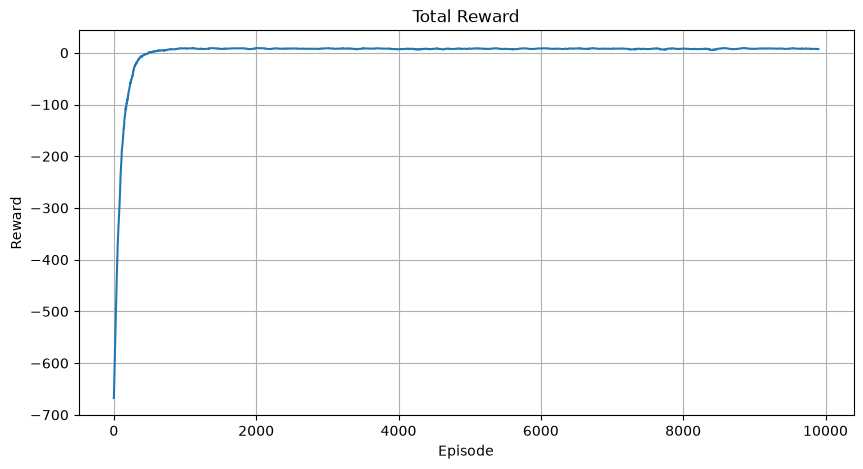

In [99]:
window = 100

reward_curve = moving_average(
    states.ep_rewards,
    window
)

show_fig(
    reward_curve,
    "Total Reward",
    "Episode",
    "Reward"
)

### Agent A Reward visualization

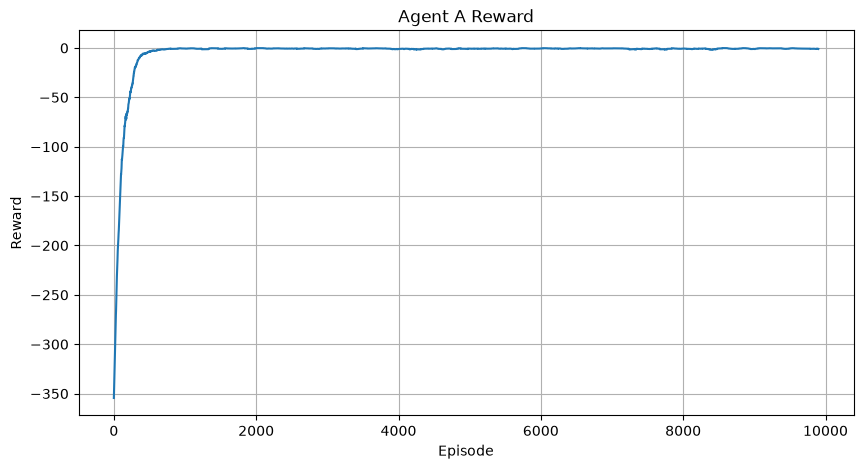

In [100]:
window = 100

reward_curve = moving_average(
    states.ep_reward_a,
    window
)

show_fig(
    reward_curve,
    "Agent A Reward",
    "Episode",
    "Reward"
)

### Agent B Reward visualization

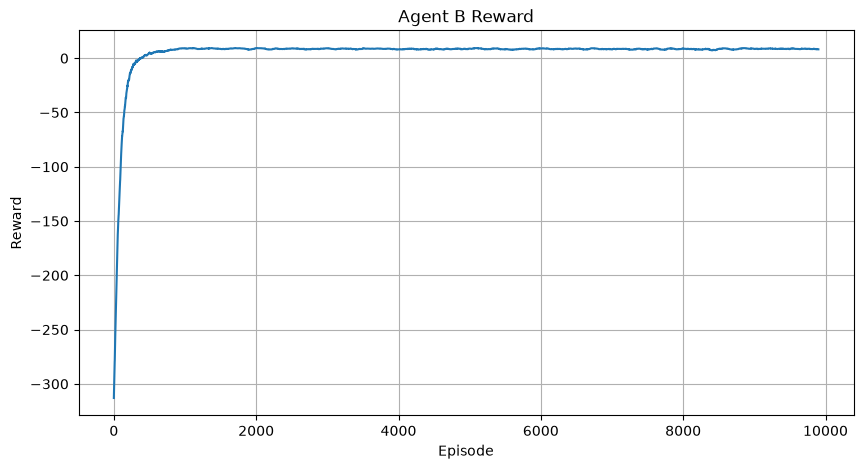

In [101]:
window = 100

reward_curve = moving_average(
    states.ep_reward_b,
    window
)

show_fig(
    reward_curve,
    "Agent B Reward",
    "Episode",
    "Reward"
)

### Mission success rate visualization

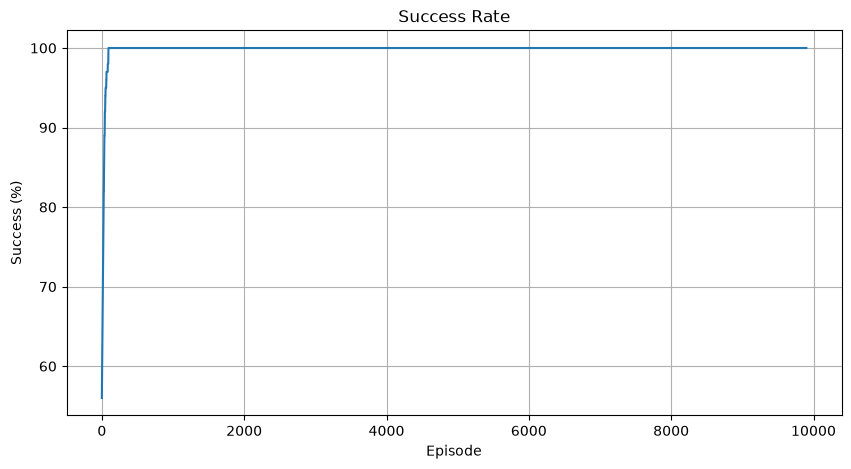

In [102]:
window = 100

success_rate = moving_average(
    states.ep_done,
    window
)

success_rate = np.array(
    success_rate
) * 100

show_fig(
    success_rate,
    "Success Rate",
    "Episode",
    "Success (%)"
)

### Episode Length Visualization

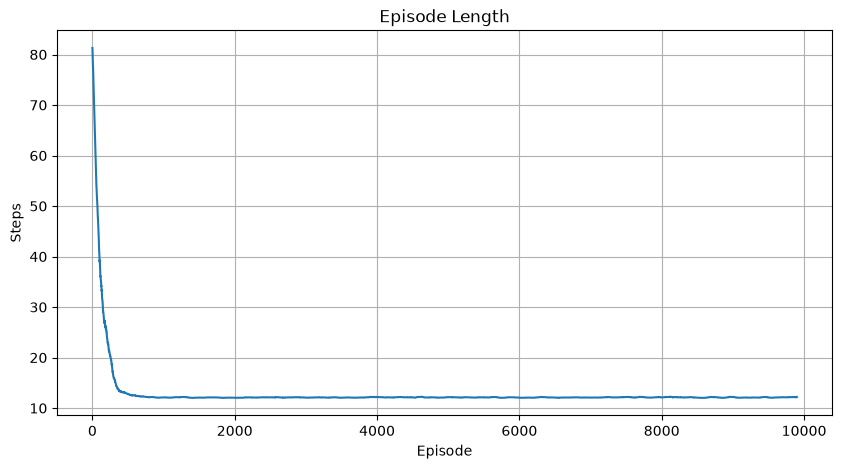

In [103]:
window = 100

step_curve = moving_average(
    states.ep_steps,
    window
)

show_fig(
    step_curve,
    "Episode Length",
    "Episode",
    "Steps"
)

### Epsilon Decay Visualization

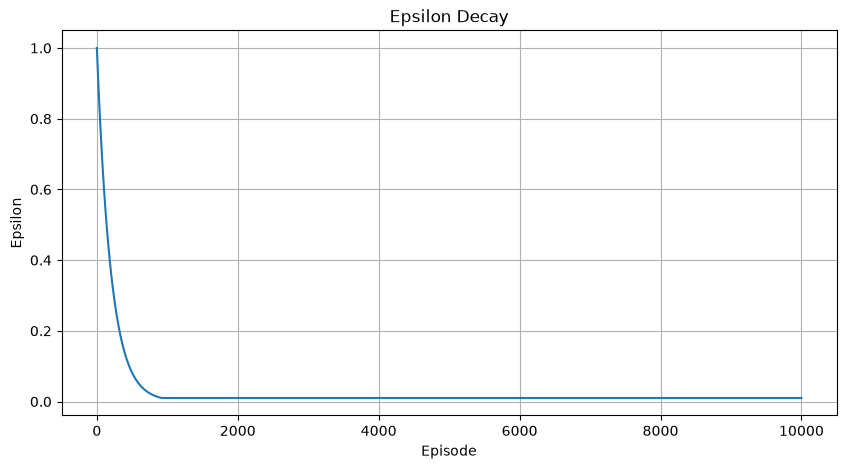

In [104]:
show_fig(
    states.epsilon_history,
    "Epsilon Decay",
    "Episode",
    "Epsilon"
)

# Demonstration

In [107]:
env = GridWorld()

state_a, state_b = env.reset()

print("=" * 50)
print("Policy Analysis")
print("=" * 50)

env.render()

for step in range(training.max_steps):

    initialize_state(
        q_table_a,
        state_a
    )

    initialize_state(
        q_table_b,
        state_b
    )

    action_a = np.argmax(
        q_table_a[state_a]
    )

    action_b = np.argmax(
        q_table_b[state_b]
    )

    (
        state_a,
        state_b,
        reward_a,
        reward_b,
        done
    ) = env.execute_action(
        action_a,
        action_b
    )

    print(f"\nStep {step + 1}")

    print(
        f"Lake: "
        f"{'Flooded' if env.is_lake_flooded else 'Dry'}"
    )

    print(
        f"Agent A -> "
        f"Position: {env.agent_a.curr_position} | "
        f"Carrying: {env.agent_a.is_carrying} | "
        f"Reward: {reward_a}"
    )

    print(
        f"Agent B -> "
        f"Position: {env.agent_b.curr_position} | "
        f"Carrying: {env.agent_b.is_carrying} | "
        f"Reward: {reward_b}"
    )

    env.render()

    if done:
        print("\nMission Completed!")
        break

Policy Analysis

. . B . .
. . . . .
. . L . U
. . . . .
A . V . .

Lake      : Flooded
A Carrying: False
B Carrying: False
A Done    : False
B Done    : False

Step 1
Lake: Flooded
Agent A -> Position: (4, 1) | Carrying: False | Reward: -5
Agent B -> Position: (1, 2) | Carrying: False | Reward: -5

. . Y . .
. . B . .
. . L . U
. . . . .
X A V . .

Lake      : Flooded
A Carrying: False
B Carrying: False
A Done    : False
B Done    : False

Step 2
Lake: Flooded
Agent A -> Position: (4, 2) | Carrying: False | Reward: -5
Agent B -> Position: (2, 2) | Carrying: False | Reward: -5

. . Y . .
. . . . .
. . B . U
. . . . .
X . A . .

Lake      : Flooded
A Carrying: False
B Carrying: False
A Done    : False
B Done    : False

Step 3
Lake: Flooded
Agent A -> Position: (3, 2) | Carrying: False | Reward: -5
Agent B -> Position: (3, 2) | Carrying: False | Reward: -5

. . Y . .
. . . . .
. . L . U
. . * . .
X . V . .

Lake      : Flooded
A Carrying: False
B Carrying: False
A Done    : False
B Done